In [1]:
import os

if not os.path.exists("/content/prism-xai"):
    !git clone https://github.com/shriyanssahoo/prism-xai.git
    %cd /content/prism-xai
else:
    %cd /content/prism-xai
    !git pull

!pip install -r requirements.txt

/content/prism-xai
remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 3 (delta 2), reused 3 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 278 bytes | 278.00 KiB/s, done.
From https://github.com/shriyanssahoo/prism-xai
   8e6b34f..bfbcf5c  main       -> origin/main
Updating 8e6b34f..bfbcf5c
Fast-forward
 requirements.txt | 2 +-
 1 file changed, 1 insertion(+), 1 deletion(-)


In [2]:
import torch
import numpy as np
import random

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print(f"Random seed set to {SEED}")

Random seed set to 42


In [3]:
import sys
for mod_name in list(sys.modules.keys()):
    if mod_name.startswith("src"):
        del sys.modules[mod_name]

from src.model_utils import load_model, load_image, get_vgg16_last_conv_layer, ActivationExtractor
from src.prism import compute_prism
from src.visualize import plot_prism_batch, plot_prism_vs_gradcam
from src.gradcam_baseline import compute_gradcam

import glob

print("All imports successful")

All imports successful


In [4]:
model = load_model("vgg16")
layer = get_vgg16_last_conv_layer(model)
extractor = ActivationExtractor(model, layer)

print("Model loaded, hook attached")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:08<00:00, 63.6MB/s]


Model loaded, hook attached


In [5]:
paths = (
    glob.glob("data/raw/timber_wolf/*")[:2] +
    glob.glob("data/raw/coyote/*")[:1]
)
print("Selected paths:", paths)

# preprocessed tensors (for the model) + original PIL images (for display)
tensors = [load_image(p)[0] for p in paths]
originals = [load_image(p)[1] for p in paths]

batch = torch.stack(tensors).to(next(model.parameters()).device)

Selected paths: ['data/raw/timber_wolf/n02114548_10024.JPEG', 'data/raw/timber_wolf/n02114548_10093.JPEG', 'data/raw/coyote/n02114855_10035.JPEG']


In [6]:
with torch.no_grad():
    model(batch)

prism_maps, top3_var, all_var = compute_prism(extractor.activations)

print("PRISM map shape:", prism_maps.shape)
print("Top-3 PC variance:", top3_var, "sum:", top3_var.sum())

PRISM map shape: (3, 3, 14, 14)
Top-3 PC variance: [0.25281637 0.14438103 0.07728306] sum: 0.47448046021776147


In [7]:
gradcam_overlays = []
predicted_classes = []

for i, (tensor, orig) in enumerate(zip(tensors, originals)):
    overlay, pred_class = compute_gradcam(model, layer, tensor, orig)
    gradcam_overlays.append(overlay)
    predicted_classes.append(pred_class)
    print(f"Image {i+1} ({paths[i]}): predicted class index = {pred_class}")

Image 1 (data/raw/timber_wolf/n02114548_10024.JPEG): predicted class index = 270
Image 2 (data/raw/timber_wolf/n02114548_10093.JPEG): predicted class index = 270
Image 3 (data/raw/coyote/n02114855_10035.JPEG): predicted class index = 280


In [8]:
import json
import urllib.request

# Standard ImageNet class index -> label mapping
url = "https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet-simple-labels.json"
with urllib.request.urlopen(url) as f:
    imagenet_labels = json.load(f)

titles = [f"{imagenet_labels[c]}" for c in predicted_classes]
print(titles)

['Alaskan tundra wolf', 'Alaskan tundra wolf', 'grey fox']


Saved to results/figures/prism_vs_gradcam_wolf_coyote.png


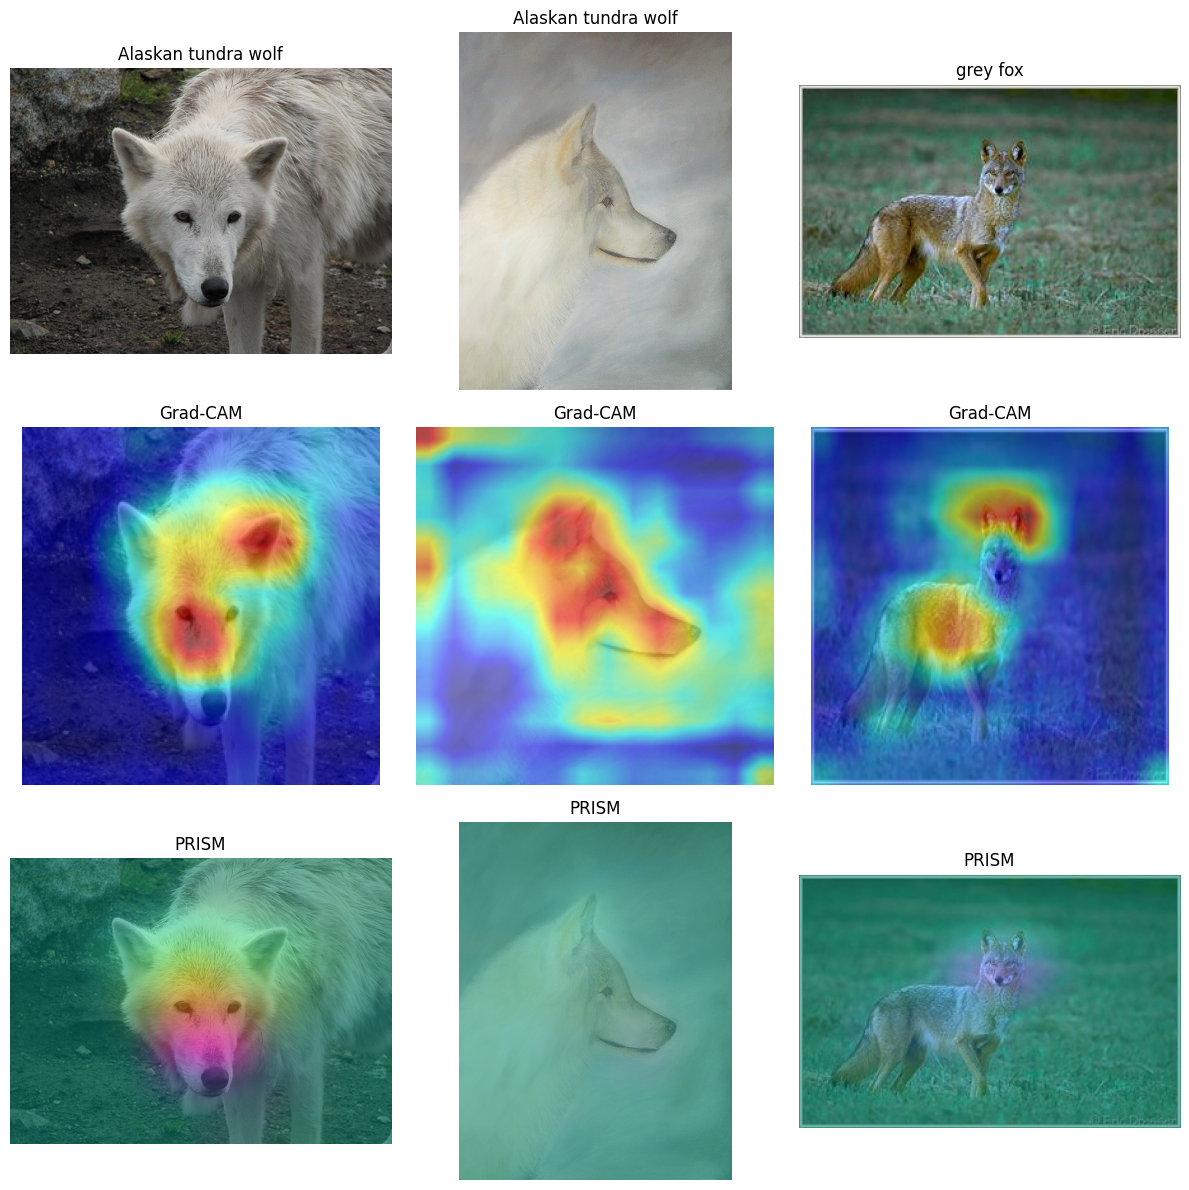

In [9]:
import os
os.makedirs("results/figures", exist_ok=True)

plot_prism_vs_gradcam(
    originals,
    prism_maps,
    gradcam_overlays,
    titles=titles,
    save_path="results/figures/prism_vs_gradcam_wolf_coyote.png"
)

Second set paths: ['data/raw/electric_locomotive/n03272562_10023.JPEG', 'data/raw/passenger_car/n03393912_10063.JPEG']
Saved to results/figures/prism_vs_gradcam_train.png


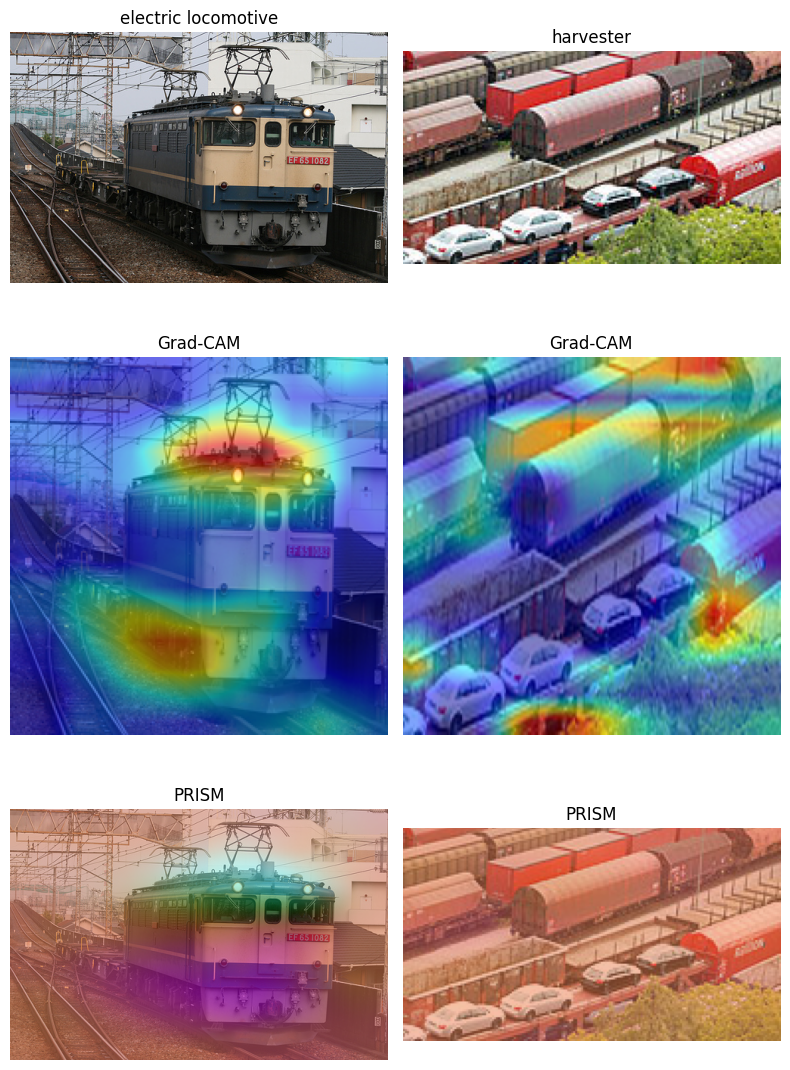

In [10]:
paths_2 = (
    glob.glob("data/raw/electric_locomotive/*")[:1] +
    glob.glob("data/raw/passenger_car/*")[:1]
)
print("Second set paths:", paths_2)

tensors_2 = [load_image(p)[0] for p in paths_2]
originals_2 = [load_image(p)[1] for p in paths_2]
batch_2 = torch.stack(tensors_2).to(next(model.parameters()).device)

with torch.no_grad():
    model(batch_2)

prism_maps_2, top3_var_2, all_var_2 = compute_prism(extractor.activations)

gradcam_overlays_2 = []
predicted_classes_2 = []
for tensor, orig in zip(tensors_2, originals_2):
    overlay, pred_class = compute_gradcam(model, layer, tensor, orig)
    gradcam_overlays_2.append(overlay)
    predicted_classes_2.append(pred_class)

titles_2 = [f"{imagenet_labels[c]}" for c in predicted_classes_2]

plot_prism_vs_gradcam(
    originals_2,
    prism_maps_2,
    gradcam_overlays_2,
    titles=titles_2,
    save_path="results/figures/prism_vs_gradcam_train.png"
)

In [11]:
import csv

os.makedirs("results/tables", exist_ok=True)

with open("results/tables/gradcam_prism_predictions.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Image Path", "Predicted Class", "Class Index"])
    for p, c, title in zip(paths, predicted_classes, titles):
        writer.writerow([p, title, c])
    for p, c, title in zip(paths_2, predicted_classes_2, titles_2):
        writer.writerow([p, title, c])

print("Saved results/tables/gradcam_prism_predictions.csv")
!cat results/tables/gradcam_prism_predictions.csv

Saved results/tables/gradcam_prism_predictions.csv
Image Path,Predicted Class,Class Index
data/raw/timber_wolf/n02114548_10024.JPEG,Alaskan tundra wolf,270
data/raw/timber_wolf/n02114548_10093.JPEG,Alaskan tundra wolf,270
data/raw/coyote/n02114855_10035.JPEG,grey fox,280
data/raw/electric_locomotive/n03272562_10023.JPEG,electric locomotive,547
data/raw/passenger_car/n03393912_10063.JPEG,harvester,595
